In [9]:
import os
import numpy as np
import pandas as pd
from glob import glob
import json
import re
import matplotlib.pyplot as plt

plot_metrics = ['anli_r1', 'anli_r2', 'anli_r3', 'hellaswag', 'lambada_standard', 'lambada_openai', 'openbookqa', 'paloma_wikitext_103', 'truthfulqa_mc2', 'winogrande', 'squad_completion', 'boolq', 'piqa', 'arc_easy', 'arc_challenge', 'gsm8k', 'mmlu', 'mmlu_pro', 'medmcqa', 'agieval_en', 'squadv2', 'drop', 'triviaqa', 'bbh', 'gpqa_main_zeroshot']

# remove the metrics that are too small and have no actual meaning.
invalid_metrics = ['gsm8k', 'mmlu_pro', 'drop', 'triviaqa', 'bbh', 'gpqa_main_zeroshot']
plot_metrics = [m for m in plot_metrics if m not in invalid_metrics]

metric_keys = [
    'acc_norm,none',
    'acc,none',
    'exact_match,strict-match',
    'exact_match,flexible-extract',
    'exact_match,custom-extract',
    'exact,none',
    'exact_match,remove_whitespace',
    'exact_match,remove_whitespace_strict',
    'exact_match,get-answer',
    'f1,none',
    'contains,none',
    'perplexity,none',
    'word_perplexity,none'
]

def extract_number_from_filename(filename):
    """Extract the number from filename like 'lm_eval_begin_0.json' or 'lm_eval_interval_1221.json'"""
    # Remove .json extension and split by underscore
    name_without_ext = filename.replace('.json', '')
    parts = name_without_ext.split('_')
    # The number is always the last part
    return int(parts[-1].replace('step', ''))

def parse_experiment_filename(filename):
    """
    Parse experiment folder name into structured components.
    
    Handles multiple formats:
    1. Standard: midtrain_{model}_{dataset}_lr-{lr}_token-{tokens}_disp-{disp_type}-{disp_value}-all_fewshot-{fewshot}_maxsample-{maxsample}_seed-{seed}{suffix}
    2. Complex: midtrain_{model}_{dataset}_{complex_params}_{hash}
    
    For complex format:
    - infonce_cosine-cXpY-taucos-ZpW means coefficient=X.Y, tau_cosine=Z.W
    - infonce_l2-cXpY-taul2-ZpW means coefficient=X.Y, tau_l2=Z.W
    - Standard format disp-infonce_*-V means coefficient=V with default tau=0.5
    
    Gradient clipping:
    - clip0.5 or old_clip05 suffix means gradient_clip=0.5
    - No clipping suffix means gradient_clip=1.0
    
    Returns dict with keys: model, dataset, lr, tokens, disp_type, disp_value, tau_cosine, tau_l2, fewshot, maxsample, seed, suffix, config_hash, gradient_clip
    """
    # Extract model name from 'midtrain_{model}_' prefix
    if not filename.startswith('midtrain_'):
        raise ValueError(f"Unexpected filename format: {filename}")
    
    name = filename[len('midtrain_'):]
    
    # Extract model name (everything up to the next underscore before dataset)
    # Model names can be: gpt2, gpt2-medium, gpt2-large, gpt2-xl, etc.
    model_match = re.match(r'^(gpt2[^_]*)_', name)
    if not model_match:
        raise ValueError(f"Could not extract model name from: {filename}")
    
    model_name = model_match.group(1)
    name = name[len(model_name) + 1:]  # +1 for the underscore
    
    result = {
        'model': model_name,
        'dataset': None,
        'lr': None,
        'tokens': None,
        'disp_type': None,
        'disp_value': None,  # coefficient
        'tau_cosine': None,  # tau parameter for cosine (default 0.5)
        'tau_l2': None,      # tau parameter for l2 (default 0.5)
        'fewshot': None,
        'maxsample': None,
        'seed': None,
        'suffix': None,
        'config_hash': None,
        'gradient_clip': 1.0  # default gradient clipping
    }
    
    # Extract dataset (first component)
    if name.startswith('Salesforce-wikitext_'):
        result['dataset'] = 'Salesforce-wikitext'
        name = name[len('Salesforce-wikitext_'):]
    elif name.startswith('Skylion007-openwebtext_'):
        result['dataset'] = 'Skylion007-openwebtext'
        name = name[len('Skylion007-openwebtext_'):]
    else:
        # Handle other datasets or complex formats
        # Look for the first underscore after a potential dataset name
        first_underscore = name.find('_')
        if first_underscore > 0:
            result['dataset'] = name[:first_underscore]
            name = name[first_underscore + 1:]
        else:
            result['dataset'] = name
            name = ''
    
    # Check if this is a complex format (contains hash at the end)
    hash_match = re.search(r'_([a-f0-9]{8,})$', name)
    if hash_match:
        result['config_hash'] = hash_match.group(1)
        name = name[:hash_match.start()]
    
    # Extract suffix if present - check for gradient clipping first
    suffix_patterns = ['old_clip05', 'clip0.5', '_old_old', '_old']
    for suffix in suffix_patterns:
        if name.endswith(suffix):
            result['suffix'] = suffix
            name = name[:-len(suffix)]
            # Set gradient clipping based on suffix
            if 'clip05' in suffix or 'clip0.5' in suffix:
                result['gradient_clip'] = 0.5
            break
    
    # Try to parse standard format components
    # lr-{lr}
    lr_match = re.search(r'lr-([0-9e\.-]+)_?', name)
    if lr_match:
        result['lr'] = lr_match.group(1)
        name = name.replace(lr_match.group(0), '', 1)
    
    # token-{tokens}
    token_match = re.search(r'token-([0-9]+)_?', name)
    if token_match:
        result['tokens'] = int(token_match.group(1))
        name = name.replace(token_match.group(0), '', 1)
    
    # disp-{disp_type}-{disp_value}
    disp_match = re.search(r'disp-([^-]+)-([^-]+)_?', name)
    if disp_match:
        result['disp_type'] = disp_match.group(1)
        result['disp_value'] = disp_match.group(2)
        # For standard format, set default tau values
        if result['disp_type'] == 'infonce_cosine':
            result['tau_cosine'] = 0.5
        elif result['disp_type'] == 'infonce_l2':
            result['tau_l2'] = 0.5
        name = name.replace(disp_match.group(0), '', 1)
    
    # all_fewshot-{fewshot}
    fewshot_match = re.search(r'all_fewshot-([0-9]+)_?', name)
    if fewshot_match:
        result['fewshot'] = int(fewshot_match.group(1))
        name = name.replace(fewshot_match.group(0), '', 1)
    
    # maxsample-{maxsample}
    maxsample_match = re.search(r'maxsample-([0-9]+)_?', name)
    if maxsample_match:
        result['maxsample'] = int(maxsample_match.group(1))
        name = name.replace(maxsample_match.group(0), '', 1)
    
    # seed-{seed}
    seed_match = re.search(r'seed-([0-9]+)_?', name)
    if seed_match:
        result['seed'] = int(seed_match.group(1))
        name = name.replace(seed_match.group(0), '', 1)
    
    # For complex formats, try to extract what we can
    if not result['disp_type'] and 'disp-' not in filename:
        # This is a complex format, try to extract dispersion info differently
        # Look for patterns like infonce_cosine-c0p1-taucos-0p1 or infonce_l2-c0p1-taul2-0p1
        complex_patterns = [
            r'infonce_cosine-c([0-9]+)p([0-9]+)-taucos-([0-9]+)p([0-9]+)',
            r'infonce_l2-c([0-9]+)p([0-9]+)-taul2-([0-9]+)p([0-9]+)'
        ]
        
        for pattern in complex_patterns:
            match = re.search(pattern, name)
            if match:
                c_int, c_dec, tau_int, tau_dec = match.groups()
                coeff = float(f"{c_int}.{c_dec}")
                tau_val = float(f"{tau_int}.{tau_dec}")
                
                result['disp_value'] = coeff  # coefficient
                if 'infonce_cosine' in name:
                    result['disp_type'] = 'infonce_cosine'
                    result['tau_cosine'] = tau_val
                elif 'infonce_l2' in name:
                    result['disp_type'] = 'infonce_l2'
                    result['tau_l2'] = tau_val
                break
        
        # Extract lr from complex format (lr1em05 -> 1e-05)
        lr_complex_match = re.search(r'lr([0-9]+)em([0-9]+)', name)
        if lr_complex_match:
            result['lr'] = f"{lr_complex_match.group(1)}e-{lr_complex_match.group(2)}"
        
        # Extract tokens from complex format (tok300M -> 300000000)
        token_complex_match = re.search(r'tok([0-9]+)M', name)
        if token_complex_match:
            result['tokens'] = int(token_complex_match.group(1)) * 1000000
        
        # Extract seed from complex format (s1 -> 1)
        seed_complex_match = re.search(r's([0-9]+)', name)
        if seed_complex_match:
            result['seed'] = int(seed_complex_match.group(1))
    
    return result    

In [10]:
res_path = "./results/"
output_csv = './results.csv'
output_dir = "./figures/all/"
os.makedirs(output_dir, exist_ok=True)

In [12]:
res_folders = os.listdir(res_path)
result_list = []
parsed_configs = []
for res_folder in res_folders:
    if not res_folder.startswith('midtrain_gpt2'):
        continue
    # Parse the experiment configuration from folder name
    try:
        config = parse_experiment_filename(res_folder)
        parsed_configs.append(config)
    except ValueError as e:
        print(f"Warning: Could not parse folder {res_folder}: {e}")
        continue
    
    files = sorted([f for f in os.listdir(os.path.join(res_path, res_folder)) if f.startswith('lm_eval_')])
    # print(f"{res_folder}")
    for file in files:
        # print(f"{file}")
        step = extract_number_from_filename(file)
        with open(f'{res_path}/{res_folder}/{file}', 'r') as f:
            data = json.load(f)

        result = {}

        result['folder_name'] = res_folder
        result['filename'] = file
        result['step'] = step
        # Add all parsed configuration components
        result.update(config)
        
        for plot_metric in plot_metrics:
            res = data['results'][plot_metric]
            key_used = None
            for key in metric_keys:
                if key in res.keys():
                    key_used = key
                    break
            assert key_used is not None, f'no key found for {plot_metric}, possible keys: {res.keys()}'
            result_value = res[key_used]
            result_key = plot_metric + ',' + key_used
            result[result_key] = result_value

        result_list.append(result)

df = pd.DataFrame(result_list).sort_values('step')
df['squadv2,exact,none'] /= 100 # normalize squadv2 to 0-1

# Identify metric columns (exclude config columns)
config_cols = ['folder_name', 'filename', 'step', 'model', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]
metric_no_ppl = [c for c in metric_cols if c != 'paloma_wikitext_103,word_perplexity,none']
df['mean_metric'] = df[metric_no_ppl].mean(axis=1)

# Check for duplicate configurations and remove them
config_cols = ['model', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'gradient_clip']

# Properly map folders to their parsed configs
config_to_folders = {}
for res_folder in res_folders:
    if not res_folder.startswith('midtrain_gpt2'):
        continue
    try:
        config = parse_experiment_filename(res_folder)
        config_key = tuple(config.get(col, '__NONE__') for col in config_cols)
        if config_key not in config_to_folders:
            config_to_folders[config_key] = []
        config_to_folders[config_key].append(res_folder)
    except ValueError:
        continue

# Find duplicates
duplicate_folders = []
folders_to_keep = []
for config_key, folder_list in config_to_folders.items():
    if len(folder_list) > 1:
        folders_to_keep.append(folder_list[0])  # Keep first
        duplicate_folders.extend(folder_list[1:])  # Mark rest for removal

if duplicate_folders:
    print(f"Found duplicate configurations - removing {len(duplicate_folders)} duplicate folders")
    print(f"Duplicate folders to remove: {duplicate_folders}")
    
    # Filter df to exclude duplicate folders
    df = df[~df['folder_name'].isin(duplicate_folders)]
    print(f"DataFrame reduced from {len(df) + len(duplicate_folders)*11} to {len(df)} rows")
else:
    print("No duplicate configurations found")

# df.to_csv(f'{output_dir}/{output_csv}', index=False)

Found duplicate configurations - removing 2 duplicate folders
Duplicate folders to remove: ['midtrain_gpt2_Salesforce-wikitext_lr-1e-05_token-300000000_disp-None-1-all_fewshot-1_maxsample-100_seed-1', 'midtrain_gpt2_Salesforce-wikitext_lr-1e-05_token-300000000_disp-infonce_l2-0.1-all_fewshot-1_maxsample-100_seed-1_old']
DataFrame reduced from 406 to 384 rows


In [34]:
config_cols = ['folder_name', 'filename', 'step', 'dataset', 'lr', 'tokens', 'disp_type', 'disp_value', 
               'tau_cosine', 'tau_l2', 'fewshot', 'maxsample', 'seed', 'suffix', 'config_hash', 'gradient_clip', 'disp']
metric_cols = [col for col in df.columns if col not in config_cols]

assert (df[(df['step'] == 0)&(df['model'] == 'gpt2')][[c for c in metric_cols if 'model' not in c]].var() < 1e-10).all()

df[df['step'] == 0][metric_cols].groupby('model').mean()

,"anli_r1,acc,none","anli_r2,acc,none","anli_r3,acc,none","hellaswag,acc_norm,none","lambada_standard,acc,none","lambada_openai,acc,none","openbookqa,acc_norm,none","paloma_wikitext_103,word_perplexity,none","truthfulqa_mc2,acc,none","winogrande,acc,none","squad_completion,contains,none","boolq,acc,none","piqa,acc_norm,none","arc_easy,acc_norm,none","arc_challenge,acc_norm,none","mmlu,acc,none","medmcqa,acc_norm,none","agieval_en,acc,none","squadv2,exact,none",mean_metric
model,,,,,,,,,,,,,,,,,,,,
gpt2,0.40,0.37,0.42,0.42,0.27,0.34,0.27,52.286709,0.452888,0.49,0.39,0.45,0.58,0.37,0.22,0.252281,0.23,0.232,0.17,0.351509
gpt2-large,0.41,0.39,0.41,0.52,0.32,0.43,0.28,29.606493,0.418631,0.63,0.50,0.70,0.73,0.48,0.22,0.264035,0.27,0.228,0.15,0.408370
gpt2-medium,0.37,0.38,0.39,0.46,0.34,0.39,0.30,35.607770,0.412553,0.54,0.45,0.75,0.72,0.41,0.28,0.246491,0.26,0.216,0.07,0.388058
gpt2-xl,0.36,0.38,0.20,0.52,0.38,0.46,0.29,26.494969,0.378899,0.61,0.53,0.61,0.75,0.51,0.31,0.254561,0.35,0.229,0.17,0.405137


/tmp/ipykernel_244720/3957791404.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_df.index, y=mean_df[metric], ax=ax, palette="tab10")
/tmp/ipykernel_244720/3957791404.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_df.index, y=mean_df[metric], ax=ax, palette="tab10")
/tmp/ipykernel_244720/3957791404.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_df.index, y=mean_df[metric], ax=ax, palette="tab10")
/tmp/ipykernel_244720/3957791404.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

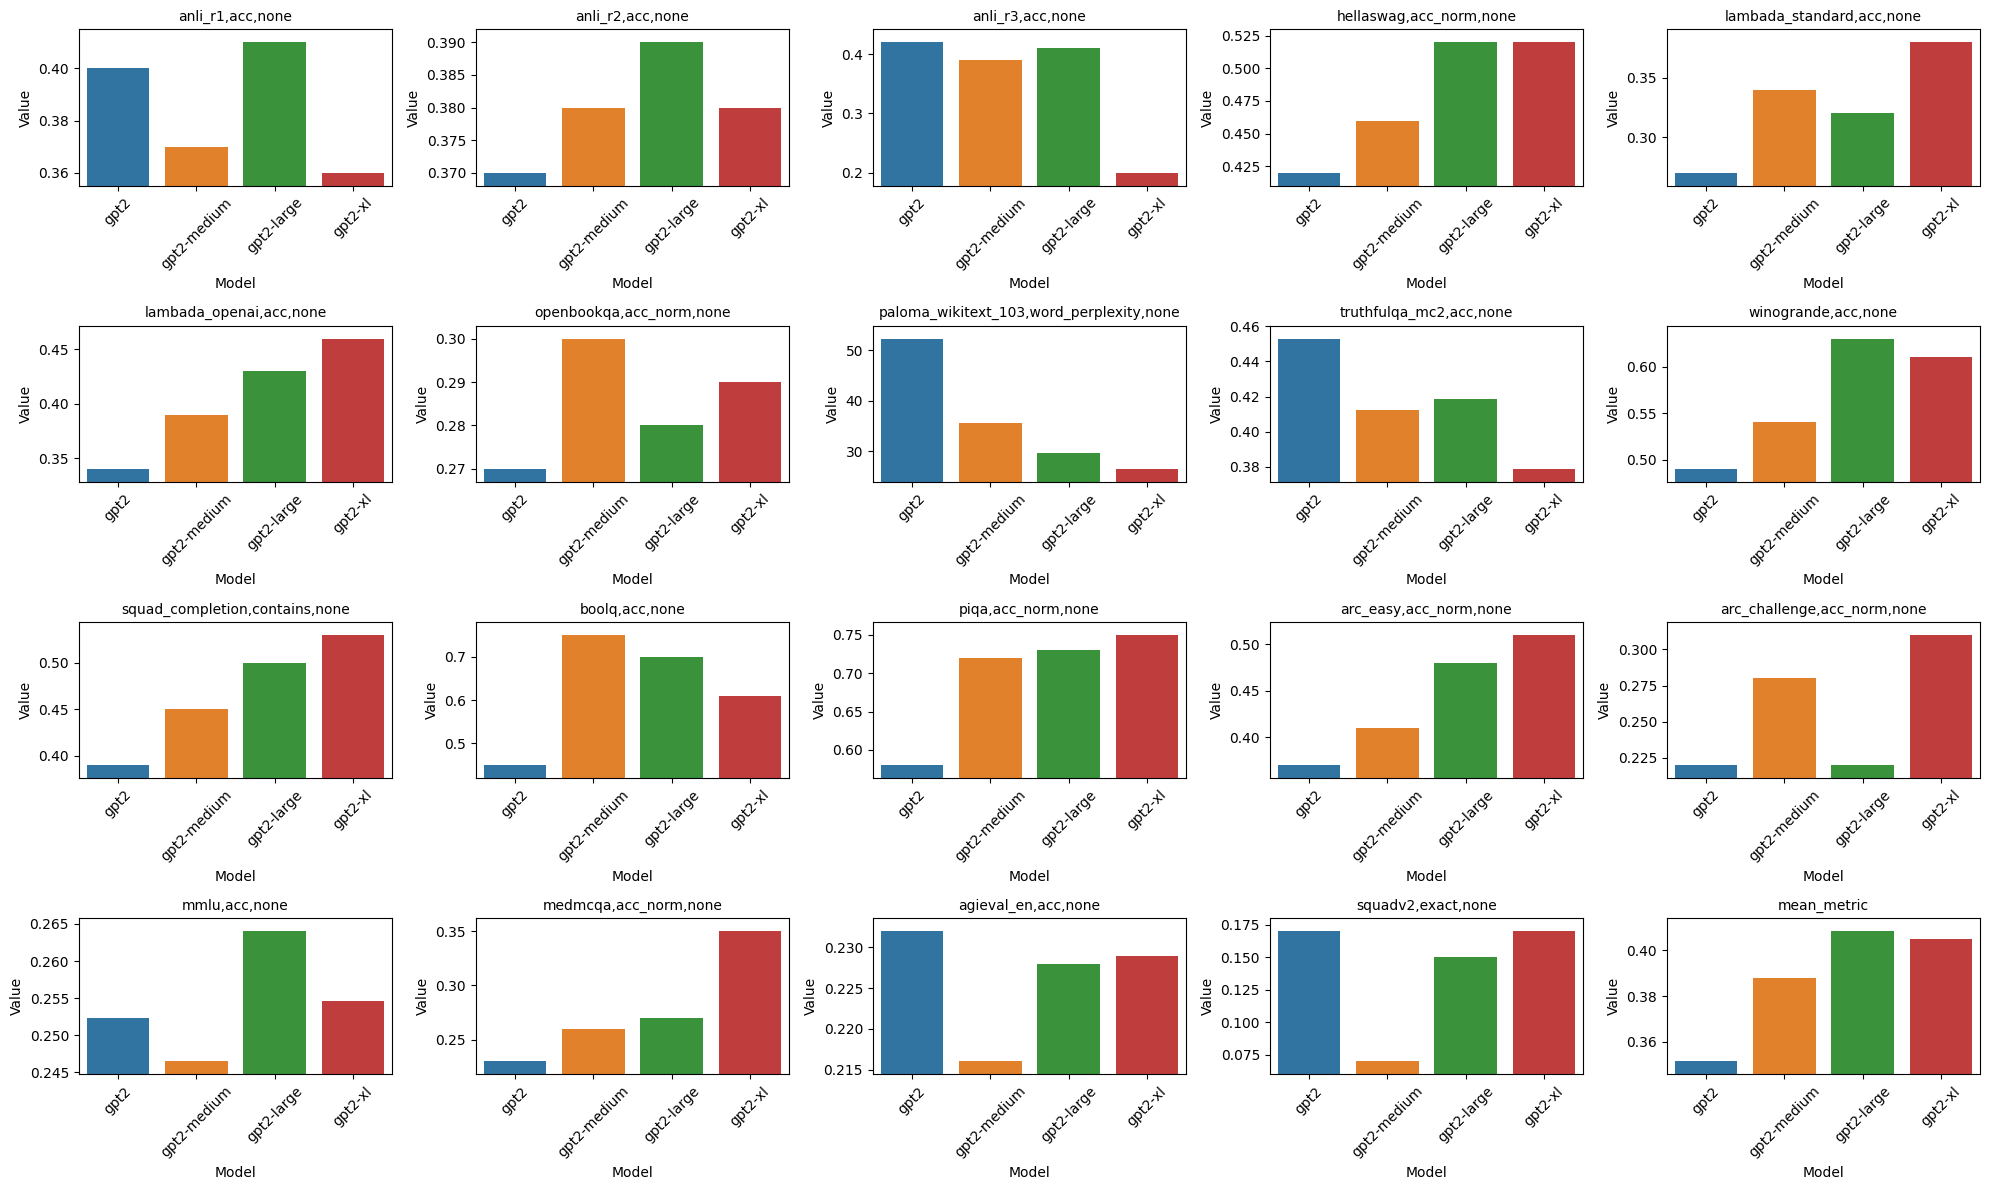

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
mean_df = df[df['step'] == 0][metric_cols].groupby('model').mean().loc[['gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl']]
mean_df.to_csv('evals_before_training.csv')

# Exclude 'mean_metric' from per-metric plots, but plot it last
metrics_to_plot = [col for col in mean_df.columns if col != 'mean_metric']
n_metrics = len(metrics_to_plot) + 1  # +1 for mean_metric

n_cols = 5
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3), squeeze=False)
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    sns.barplot(x=mean_df.index, y=mean_df[metric], ax=ax, palette="tab10")
    ax.set_title(metric, fontsize=10)
    ax.set_xlabel("Model")
    ax.set_ylabel("Value")
    ax.tick_params(axis='x', rotation=45)
    # Set y-lims around the min/max of this metric, with a small margin
    min_val = mean_df[metric].min()
    max_val = mean_df[metric].max()
    margin = (max_val - min_val) * 0.1 if max_val > min_val else 0.05
    ax.set_ylim(min_val - margin, max_val + margin)

# Plot mean_metric in the last subplot
ax = axes[len(metrics_to_plot)]
sns.barplot(x=mean_df.index, y=mean_df['mean_metric'], ax=ax, palette="tab10")
ax.set_title('mean_metric', fontsize=10)
ax.set_xlabel("Model")
ax.set_ylabel("Value")
ax.tick_params(axis='x', rotation=45)
# Set y-lims for mean_metric as well
min_val = mean_df['mean_metric'].min()
max_val = mean_df['mean_metric'].max()
margin = (max_val - min_val) * 0.1 if max_val > min_val else 0.05
ax.set_ylim(min_val - margin, max_val + margin)

# Hide any unused subplots
for j in range(len(metrics_to_plot)+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [38]:
df[df['step'] == 0][metric_cols].groupby('model').mean().loc['gpt2']

anli_r1,acc,none                             0.400000
anli_r2,acc,none                             0.370000
anli_r3,acc,none                             0.420000
hellaswag,acc_norm,none                      0.420000
lambada_standard,acc,none                    0.270000
lambada_openai,acc,none                      0.340000
openbookqa,acc_norm,none                     0.270000
paloma_wikitext_103,word_perplexity,none    52.286709
truthfulqa_mc2,acc,none                      0.452888
winogrande,acc,none                          0.490000
squad_completion,contains,none               0.390000
boolq,acc,none                               0.450000
piqa,acc_norm,none                           0.580000
arc_easy,acc_norm,none                       0.370000
arc_challenge,acc_norm,none                  0.220000
mmlu,acc,none                                0.252281
medmcqa,acc_norm,none                        0.230000
agieval_en,acc,none                          0.232000
squadv2,exact,none          

In [40]:
mean_df

,"anli_r1,acc,none","anli_r2,acc,none","anli_r3,acc,none","hellaswag,acc_norm,none","lambada_standard,acc,none","lambada_openai,acc,none","openbookqa,acc_norm,none","paloma_wikitext_103,word_perplexity,none","truthfulqa_mc2,acc,none","winogrande,acc,none","squad_completion,contains,none","boolq,acc,none","piqa,acc_norm,none","arc_easy,acc_norm,none","arc_challenge,acc_norm,none","mmlu,acc,none","medmcqa,acc_norm,none","agieval_en,acc,none","squadv2,exact,none",mean_metric
model,,,,,,,,,,,,,,,,,,,,
gpt2,0.40,0.37,0.42,0.42,0.27,0.34,0.27,52.286709,0.452888,0.49,0.39,0.45,0.58,0.37,0.22,0.252281,0.23,0.232,0.17,0.351509
gpt2-medium,0.37,0.38,0.39,0.46,0.34,0.39,0.30,35.607770,0.412553,0.54,0.45,0.75,0.72,0.41,0.28,0.246491,0.26,0.216,0.07,0.388058
gpt2-large,0.41,0.39,0.41,0.52,0.32,0.43,0.28,29.606493,0.418631,0.63,0.50,0.70,0.73,0.48,0.22,0.264035,0.27,0.228,0.15,0.408370
gpt2-xl,0.36,0.38,0.20,0.52,0.38,0.46,0.29,26.494969,0.378899,0.61,0.53,0.61,0.75,0.51,0.31,0.254561,0.35,0.229,0.17,0.405137


In [42]:
mean_df - mean_df.loc['gpt2']

,"anli_r1,acc,none","anli_r2,acc,none","anli_r3,acc,none","hellaswag,acc_norm,none","lambada_standard,acc,none","lambada_openai,acc,none","openbookqa,acc_norm,none","paloma_wikitext_103,word_perplexity,none","truthfulqa_mc2,acc,none","winogrande,acc,none","squad_completion,contains,none","boolq,acc,none","piqa,acc_norm,none","arc_easy,acc_norm,none","arc_challenge,acc_norm,none","mmlu,acc,none","medmcqa,acc_norm,none","agieval_en,acc,none","squadv2,exact,none",mean_metric
model,,,,,,,,,,,,,,,,,,,,
gpt2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00,0.00,0.000000,0.00,0.000,0.00,0.000000
gpt2-medium,-0.03,0.01,-0.03,0.04,0.07,0.05,0.03,-16.678939,-0.040335,0.05,0.06,0.30,0.14,0.04,0.06,-0.005789,0.03,-0.016,-0.10,0.036549
gpt2-large,0.01,0.02,-0.01,0.10,0.05,0.09,0.01,-22.680216,-0.034257,0.14,0.11,0.25,0.15,0.11,0.00,0.011754,0.04,-0.004,-0.02,0.056861
gpt2-xl,-0.04,0.01,-0.22,0.10,0.11,0.12,0.02,-25.791740,-0.073989,0.12,0.14,0.16,0.17,0.14,0.09,0.002281,0.12,-0.003,0.00,0.053627
